<a href="https://colab.research.google.com/github/BetinaBiju/internship-project/blob/main/Question%205%20%26%206.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving production_data.csv to production_data.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("production_data.csv")

df.head()

,Timestamp,MachineID,Plant,Temperature,Vibration,Pressure,EnergyConsumption,ProductionUnits,DefectCount,MaintenanceFlag,Date,Hour
0,1/1/2025 0:00,146,Plant_B,73.640197,6.352966,31.046956,267.080837,85,5,0,1/1/2025 0:00,0
1,1/1/2025 1:00,105,Plant_C,72.551754,6.551188,24.691102,278.771944,88,3,1,1/1/2025 0:00,1
2,1/1/2025 2:00,101,Plant_C,69.140439,7.965381,30.900484,360.659703,187,2,0,1/1/2025 0:00,2
3,1/1/2025 3:00,140,Plant_C,63.369086,4.810562,32.181339,159.033389,93,3,0,1/1/2025 0:00,3
4,1/1/2025 4:00,123,Plant_C,70.358221,3.470875,26.553560,220.646146,117,3,0,1/1/2025 0:00,4


Creating the Date column & Hour column

used for time-series analysis

In [4]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

df['Date'] = df['Timestamp'].dt.date
df['Hour'] = df['Timestamp'].dt.hour

**Q5 Time-Series Forecasting (Next 14 Days)**

In [5]:
daily_production = df.groupby(['Plant','Date'])['ProductionUnits'].sum().reset_index()

daily_production.head()

,Plant,Date,ProductionUnits
0,Plant_A,2025-01-01,615
1,Plant_A,2025-01-02,1343
2,Plant_A,2025-01-03,1196
3,Plant_A,2025-01-04,804
4,Plant_A,2025-01-05,1653


In [6]:
plant_data = daily_production[daily_production['Plant'] == daily_production['Plant'].unique()[0]]

plant_data = plant_data.sort_values('Date')

In [7]:
plant_data['NaiveForecast'] = plant_data['ProductionUnits'].shift(1)

plant_data.head()

,Plant,Date,ProductionUnits,NaiveForecast
0,Plant_A,2025-01-01,615,NaN
1,Plant_A,2025-01-02,1343,615.0
2,Plant_A,2025-01-03,1196,1343.0
3,Plant_A,2025-01-04,804,1196.0
4,Plant_A,2025-01-05,1653,804.0


In [8]:
plant_data['NaiveForecast'] = plant_data['ProductionUnits'].shift(1)

plant_data.head()

,Plant,Date,ProductionUnits,NaiveForecast
0,Plant_A,2025-01-01,615,NaN
1,Plant_A,2025-01-02,1343,615.0
2,Plant_A,2025-01-03,1196,1343.0
3,Plant_A,2025-01-04,804,1196.0
4,Plant_A,2025-01-05,1653,804.0


In [9]:
from sklearn.linear_model import LinearRegression

plant_data = plant_data.reset_index(drop=True)

plant_data['DayIndex'] = plant_data.index

X = plant_data[['DayIndex']]
y = plant_data['ProductionUnits']

model = LinearRegression()

model.fit(X, y)

LinearRegression()

In [10]:
future_days = pd.DataFrame({
    'DayIndex': range(plant_data['DayIndex'].max()+1,
                      plant_data['DayIndex'].max()+15)
})

forecast = model.predict(future_days)

forecast

array([950.39650968, 950.32807013, 950.25963057, 950.19119102,
       950.12275146, 950.05431191, 949.98587235, 949.9174328 ,
       949.84899324, 949.78055369, 949.71211413, 949.64367458,
       949.57523502, 949.50679547])

In [11]:
from sklearn.metrics import mean_absolute_percentage_error

predictions = model.predict(X)

mape = mean_absolute_percentage_error(y, predictions)

print("MAPE:", mape)

MAPE: 0.3344573666017192


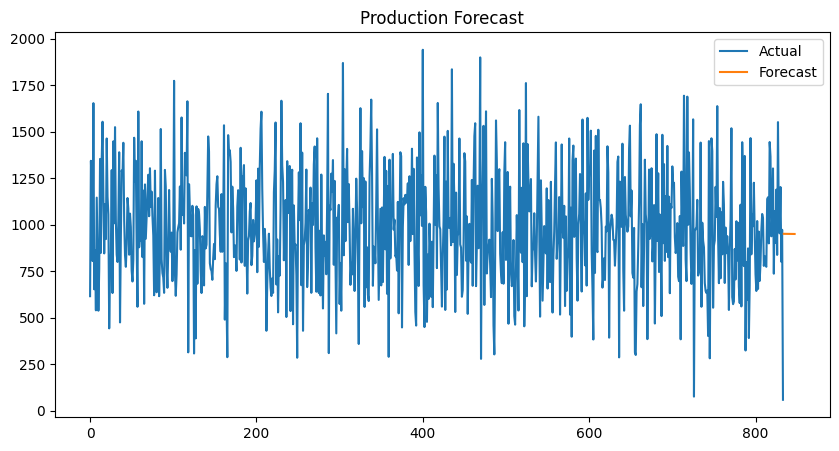

In [12]:
plt.figure(figsize=(10,5))

plt.plot(plant_data['DayIndex'], plant_data['ProductionUnits'], label='Actual')

plt.plot(future_days['DayIndex'], forecast, label='Forecast')

plt.legend()

plt.title("Production Forecast")

plt.show()

**Q6 Classification**

In [13]:
threshold = df['ProductionUnits'].quantile(0.10)

df['LowOutputEvent'] = (df['ProductionUnits'] < threshold).astype(int)

df[['ProductionUnits','LowOutputEvent']].head()

,ProductionUnits,LowOutputEvent
0,85,0
1,88,0
2,187,0
3,93,0
4,117,0


In [14]:
features = ['EnergyConsumption']

X = df[features]

y = df['LowOutputEvent']

In [15]:
features = ['EnergyConsumption','Temperature','Pressure']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [18]:
pred = model.predict(X_test)

In [19]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, pred)

print("F1 Score:", f1)

F1 Score: 0.09848484848484848


In [20]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, pred)

array([[3247,  348],
       [ 366,   39]])